In [112]:
import pandas as pd
import matplotlib.pyplot as plt

In [113]:
# Path to your event log CSV
log_path = "D:/Projects/Big/opra/data/logs/AcademicCredentials/AcademicCredentials_train.csv"

# Read log
df_log = pd.read_csv(log_path)

# Detect case id column
if "case_id" in df_log.columns:
    case_col = "case_id"
elif "case" in df_log.columns:
    case_col = "case"

else:
    raise ValueError("No case id column found. Expected 'caseid' or 'case'.")

# Group by case id (number of events per case)
cases_grouped = df_log.groupby(case_col).size().reset_index(name="num_events")

# Number of cases
num_cases = cases_grouped.shape[0]
print(f"Number of cases: {num_cases}")

# cases_grouped.head()

Number of cases: 398


In [114]:
df_agents = pd.read_csv("./data/training_runs/AcademicCredentials_DDPS_p80_800_1200/update_metrics.csv")

df_agents.head()

,update,episode,policy_loss,value_loss,entropy,total_loss,approx_kl,clip_fraction
0,1,1,-0.064412,0.500373,5.148790,0.384473,NaN,NaN
1,2,2,-0.040233,0.498119,5.141289,0.406473,NaN,NaN
2,3,3,-0.018630,0.496116,5.146047,0.426025,NaN,NaN
3,4,4,-0.002731,0.496281,5.142505,0.442125,NaN,NaN
4,5,5,0.007504,0.494072,5.135668,0.450220,NaN,NaN


In [115]:
df_episode = pd.read_csv("./data/training_runs/AcademicCredentials_DDPS_p80_800_1200/episode_metrics.csv")

df_episode

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
0,1,455.667624,5203,800,611,0.76375,768912.270275,501543.000000,831432.926239,103.0,5600293.0,1138849.50,1.881864e+06,2579711.70,12.094496,NaN
1,2,440.181398,5101,800,602,0.75250,763173.301584,530483.352213,813893.631239,140.0,4547366.0,1165132.25,1.872786e+06,2420533.65,14.109124,NaN
2,3,456.485149,5106,800,614,0.76750,726883.796349,432463.000000,806978.671254,189.0,4147924.0,1129790.00,1.971557e+06,2454024.45,15.957082,NaN
3,4,451.064992,5090,800,612,0.76500,730617.124278,526024.500000,767893.015944,99.0,4838575.0,1151509.25,1.796253e+06,2282494.25,14.494415,NaN
4,5,433.970089,5064,800,602,0.75250,759034.944667,519515.550000,814208.946249,192.0,4312622.0,1167749.25,1.968213e+06,2651396.76,16.182089,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,485.015194,3327,800,635,0.79375,664434.518070,339543.000000,767692.236211,100.0,3098617.0,1032194.00,1.812565e+06,2258425.25,7.395753,NaN
296,297,513.369022,3370,800,649,0.81125,616886.312950,275399.500000,706530.233122,98.0,3099413.0,995417.50,1.496174e+06,2039006.95,7.597980,NaN
297,298,511.503423,3399,800,648,0.81000,650466.414721,384614.000000,733655.343924,98.0,3102110.0,1005546.00,1.805845e+06,2220911.35,7.718132,NaN
298,299,499.512722,3397,800,640,0.80000,624871.812450,232886.000000,773024.910601,98.0,3646405.0,962881.75,1.811670e+06,2252148.35,7.684785,NaN


In [116]:
df_episode.describe()

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
count,300.000000,300.000000,300.000000,300.0,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,300.000000,0.0
mean,150.500000,510.443938,3416.936667,800.0,645.830000,0.807287,643311.379067,311765.718257,752619.181201,106.053333,3.341677e+06,1.001285e+06,1.770160e+06,2.251021e+06,8.190652,NaN
std,86.746758,25.521543,390.124951,0.0,13.741076,0.017176,36515.368850,80410.540698,28595.255285,16.266710,5.047925e+05,5.518595e+04,1.424394e+05,1.055068e+05,1.514423,NaN
min,1.000000,407.176174,3210.000000,800.0,591.000000,0.738750,559170.203737,174278.000000,675490.332336,98.000000,3.084195e+06,9.285585e+05,1.373280e+06,1.975706e+06,7.143763,NaN
25%,75.750000,495.130255,3262.000000,800.0,638.000000,0.797500,619151.212255,256324.625000,733651.786530,98.000000,3.106617e+06,9.589666e+05,1.795060e+06,2.220658e+06,7.516716,NaN
50%,150.500000,511.909144,3294.000000,800.0,646.000000,0.807500,640432.407168,284209.750000,752469.193576,100.000000,3.128077e+06,9.949631e+05,1.803585e+06,2.259083e+06,7.684163,NaN
75%,225.250000,526.222634,3371.000000,800.0,654.000000,0.817500,661739.659092,380925.000000,768153.330186,104.000000,3.280868e+06,1.018734e+06,1.815193e+06,2.297976e+06,8.004331,NaN
max,300.000000,572.549168,5203.000000,800.0,679.000000,0.848750,781481.069749,536197.515000,844421.380809,204.000000,5.781999e+06,1.204169e+06,1.979359e+06,2.657699e+06,16.182089,NaN


C:\Users\david\AppData\Local\Temp\ipykernel_2152\2815139290.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


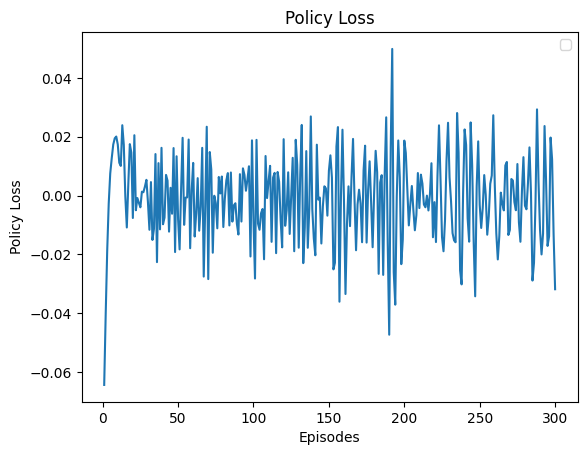

In [117]:
plt.plot(df_agents["episode"], df_agents['policy_loss'])
plt.xlabel("Episodes")
plt.ylabel("Policy Loss")
plt.title("Policy Loss")
plt.legend()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_2152\1478400342.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


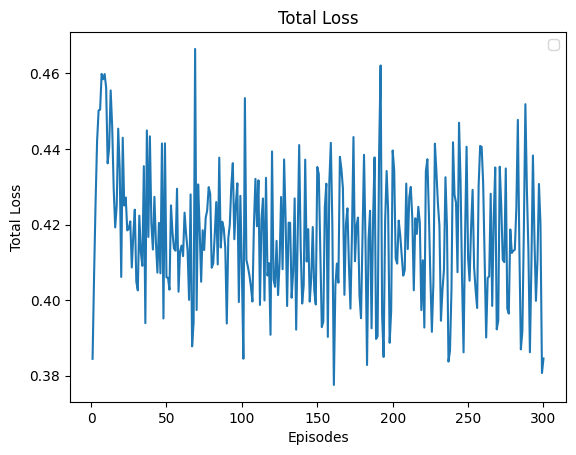

In [118]:
plt.plot(df_agents["episode"], df_agents['total_loss'])
plt.xlabel("Episodes")
plt.ylabel("Total Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_2152\1471025587.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


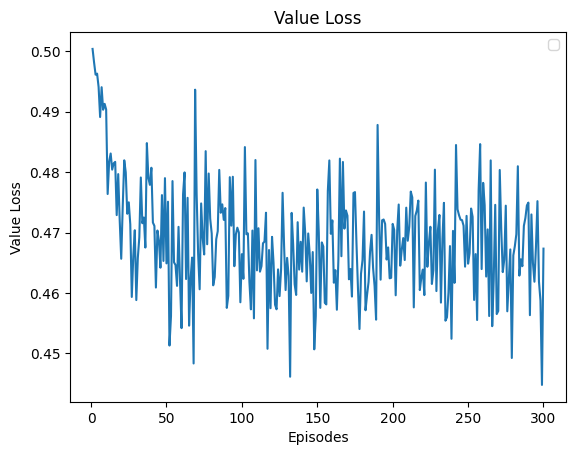

In [119]:
plt.plot(df_agents["episode"], df_agents['value_loss'])
plt.xlabel("Episodes")
plt.ylabel("Value Loss")
plt.title("Value Loss")
plt.legend()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_2152\2094019363.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


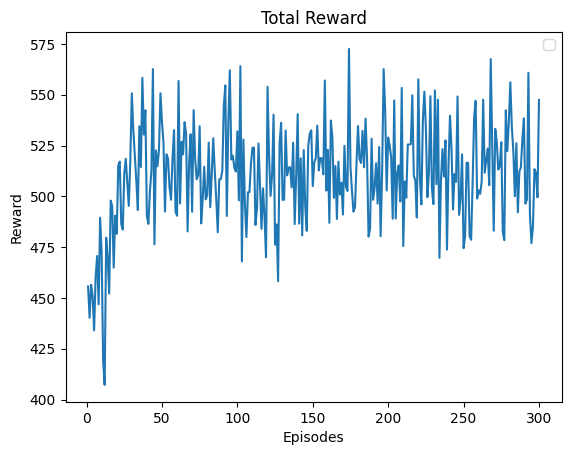

In [120]:
plt.plot(df_episode["episode"], df_episode['total_reward'])
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Total Reward")
plt.legend()
plt.show()